In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/avirajsingh/perovskites_data.csv")

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
  Material_ID Formula  Band_Gap  Formation_Energy_Per_Atom     Volume
0  mp-1183115  AcAlO3    4.1024                  -3.690019  57.451413
1  mp-1183052   AcBO3    0.8071                  -2.475390  51.548126
2   mp-866101  AcCrO3    2.0031                  -3.138972  61.362845
3   mp-864606  AcCuO3    0.0000                  -2.422892  59.929387
4   mp-861502  AcFeO3    1.0084                  -2.771539  61.797311


In [5]:
# 1. Domain-Driven Cleaning
# Assuming 'df' is your dataset and has a 'Bandgap' column
initial_count = len(df)

In [7]:
# Filter out physically impossible bandgaps (e.g., > 20 eV)
df_clean = df[df['Band_Gap'] <= 20.0]
dropped_count = initial_count - len(df_clean)
print(f"Domain cleaning removed {dropped_count} implausible entries.")

Domain cleaning removed 0 implausible entries.


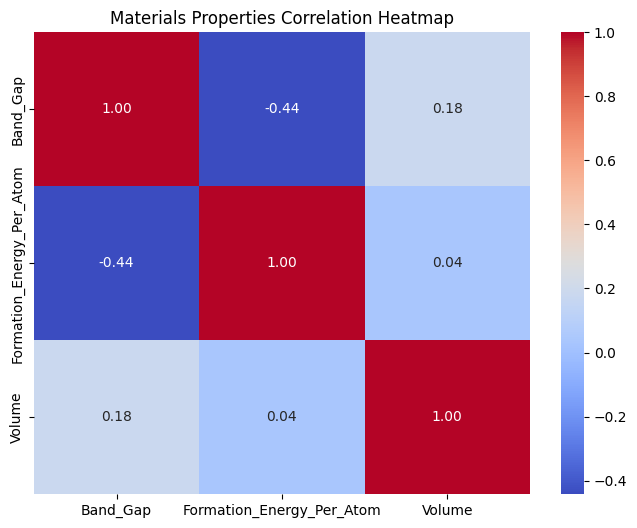

In [8]:
# 2. Correlation Heatmap
plt.figure(figsize=(8, 6))
# Select only numeric columns for correlation
numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Materials Properties Correlation Heatmap")
plt.show()

In [9]:
# 3. Pairplot for 4 Key Properties
# Replace with actual column names from the dataset (e.g., Volume, Formation Energy, etc.)
key_features = ['Bandgap', 'Density', 'Volume', 'Formation_Energy'] 
# Ensure the columns exist in your dataframe before plotting
if all(feature in df_clean.columns for feature in key_features):
    sns.pairplot(df_clean[key_features])
    plt.show()

In [10]:
# 4. Save the Cleaned Dataset
df_clean.to_csv('cleaned_materials_dataset.csv', index=False)
print("Cleaned dataset successfully saved!")

Cleaned dataset successfully saved!
